In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("accident_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)

         STATE/UT  Year                     CAUSE  Male  Female  Total  Hour  \
0  ANDHRA PRADESH  2001  Truck/Lorry (Government)   103      26    129     6   
1  ANDHRA PRADESH  2001     Truck/Lorry (Private)  2171     414   2585    19   
2  ANDHRA PRADESH  2001          Bus (Government)   488     119    607    14   
3  ANDHRA PRADESH  2001             Bus (Private)   289      76    365    10   
4  ANDHRA PRADESH  2001   Tempo/Vans (Government)    13       3     16     7   

  Time_Category  Speed  Speed_Limit Road_Condition Weather  
0       Morning     45           40        Damaged   Windy  
1       Evening     59           40            Dry   Windy  
2     Afternoon     53           60         Gravel   Windy  
3       Morning     36           40           Snow   Rainy  
4       Morning     41           80         Gravel   Windy  
(9576, 12)
Index(['STATE/UT', 'Year', 'CAUSE', 'Male', 'Female', 'Total', 'Hour',
       'Time_Category', 'Speed', 'Speed_Limit', 'Road_Condition', 'Weat

In [3]:

df[df.select_dtypes(include=np.number).columns] = df.select_dtypes(include=np.number).fillna(
    df.select_dtypes(include=np.number).mean()
)

df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna(
    df.select_dtypes(include='object').mode().iloc[0]
)

print(df.isnull().sum())

STATE/UT          0
Year              0
CAUSE             0
Male              0
Female            0
Total             0
Hour              0
Time_Category     0
Speed             0
Speed_Limit       0
Road_Condition    0
Weather           0
dtype: int64


C:\Users\nikpr\AppData\Local\Temp\ipykernel_5780\2105924063.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna(
C:\Users\nikpr\AppData\Local\Temp\ipykernel_5780\2105924063.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https:/

In [4]:
print(df.describe())
print(df.select_dtypes(include=np.number).mean())
print(df.select_dtypes(include=np.number).median())

              Year           Male        Female          Total         Hour  \
count  9576.000000    9576.000000   9576.000000    9576.000000  9576.000000   
mean   2006.500000     891.516291    161.364975    1052.881266    11.621449   
std       3.452233    5168.233111    916.329710    6079.612981     6.946260   
min    2001.000000       0.000000      0.000000       0.000000     0.000000   
25%    2003.750000       3.000000      0.000000       3.000000     6.000000   
50%    2006.500000      41.000000      7.000000      50.000000    12.000000   
75%    2009.250000     294.250000     58.000000     353.250000    18.000000   
max    2012.000000  118533.000000  20558.000000  139091.000000    23.000000   

             Speed  Speed_Limit  
count  9576.000000  9576.000000  
mean     50.197264    60.037594  
std      13.748317    16.243533  
min      20.000000    40.000000  
25%      41.000000    40.000000  
50%      50.000000    60.000000  
75%      60.000000    80.000000  
max      80.0000

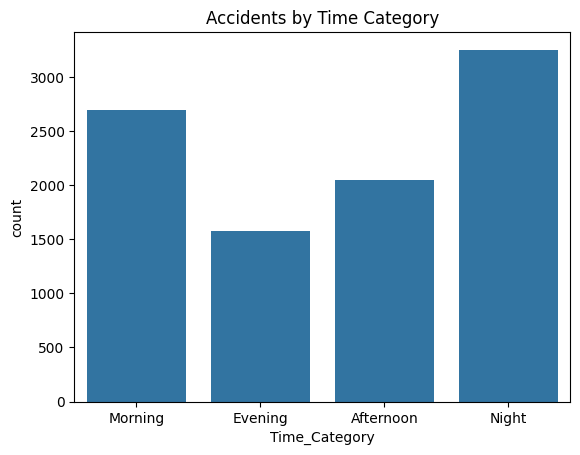

In [5]:
sns.countplot(x='Time_Category', data=df)
plt.title("Accidents by Time Category")
plt.show()

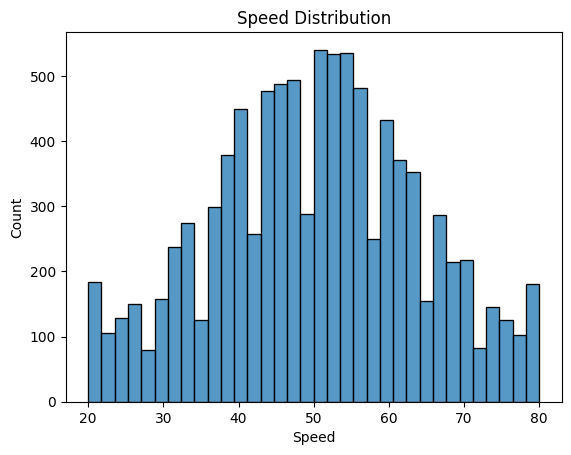

In [6]:
sns.histplot(df['Speed'])
plt.title("Speed Distribution")
plt.show()

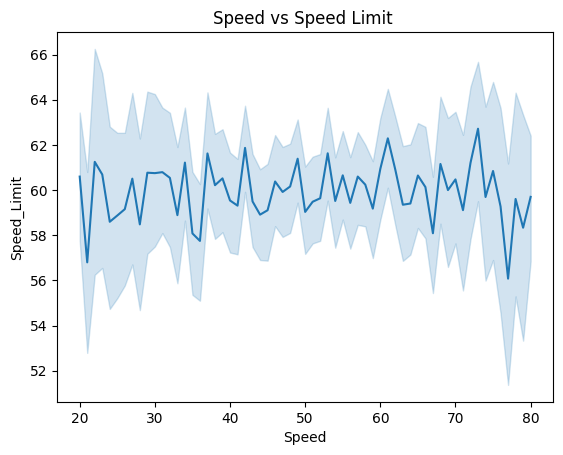

In [7]:
import seaborn as sns
df_sorted = df.sort_values(by='Speed')
sns.lineplot(x='Speed', y='Speed_Limit', data=df_sorted)
plt.title("Speed vs Speed Limit ")
plt.show()

Weather
Windy     1987
Rainy     1918
Clear     1899
Cloudy    1888
Fog       1884
Name: count, dtype: int64


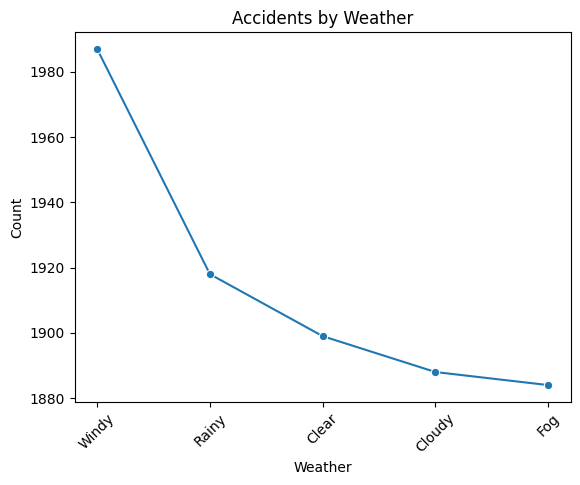

In [8]:
weather_counts = df['Weather'].value_counts()
print(weather_counts)
weather_df = weather_counts.reset_index()
weather_df.columns = ['Weather', 'Count']
import seaborn as sns

sns.lineplot(x='Weather', y='Count', data=weather_df, marker='o')

plt.title("Accidents by Weather")
plt.xticks(rotation=45)
plt.show()

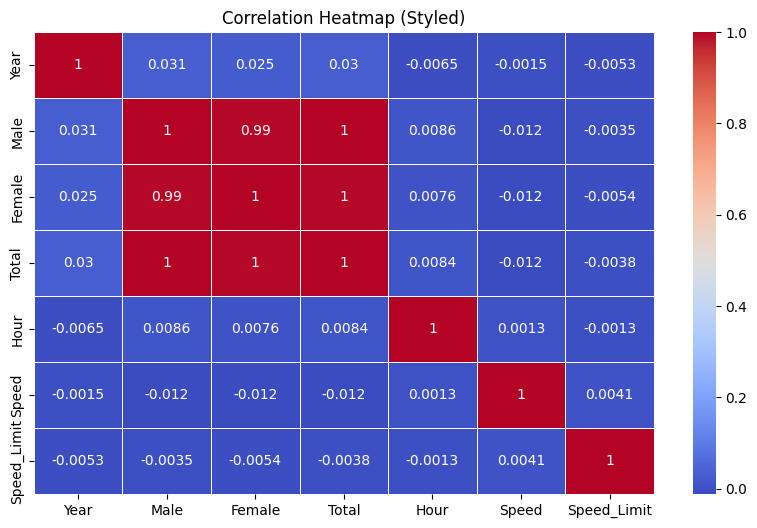

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            linewidths=0.5)

plt.title("Correlation Heatmap (Styled)")
plt.show()

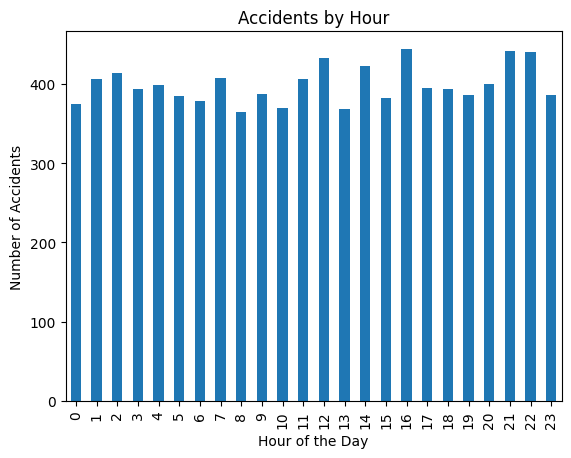

In [10]:
df['Hour'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Hour of the Day")
plt.ylabel("Number of Accidents")  
plt.title("Accidents by Hour")

plt.show()

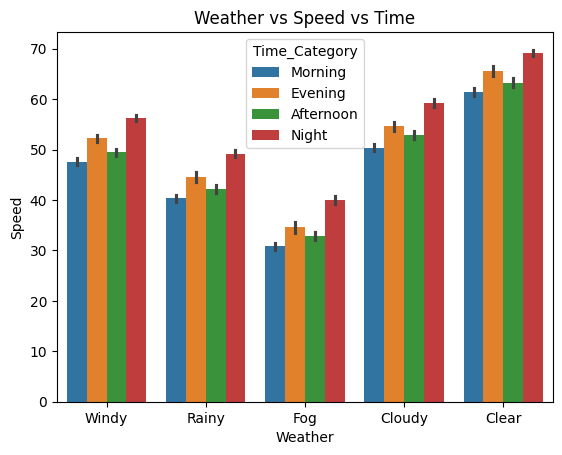

In [11]:
sns.barplot(x='Weather', y='Speed', hue='Time_Category', data=df)
plt.title("Weather vs Speed vs Time")
plt.show()

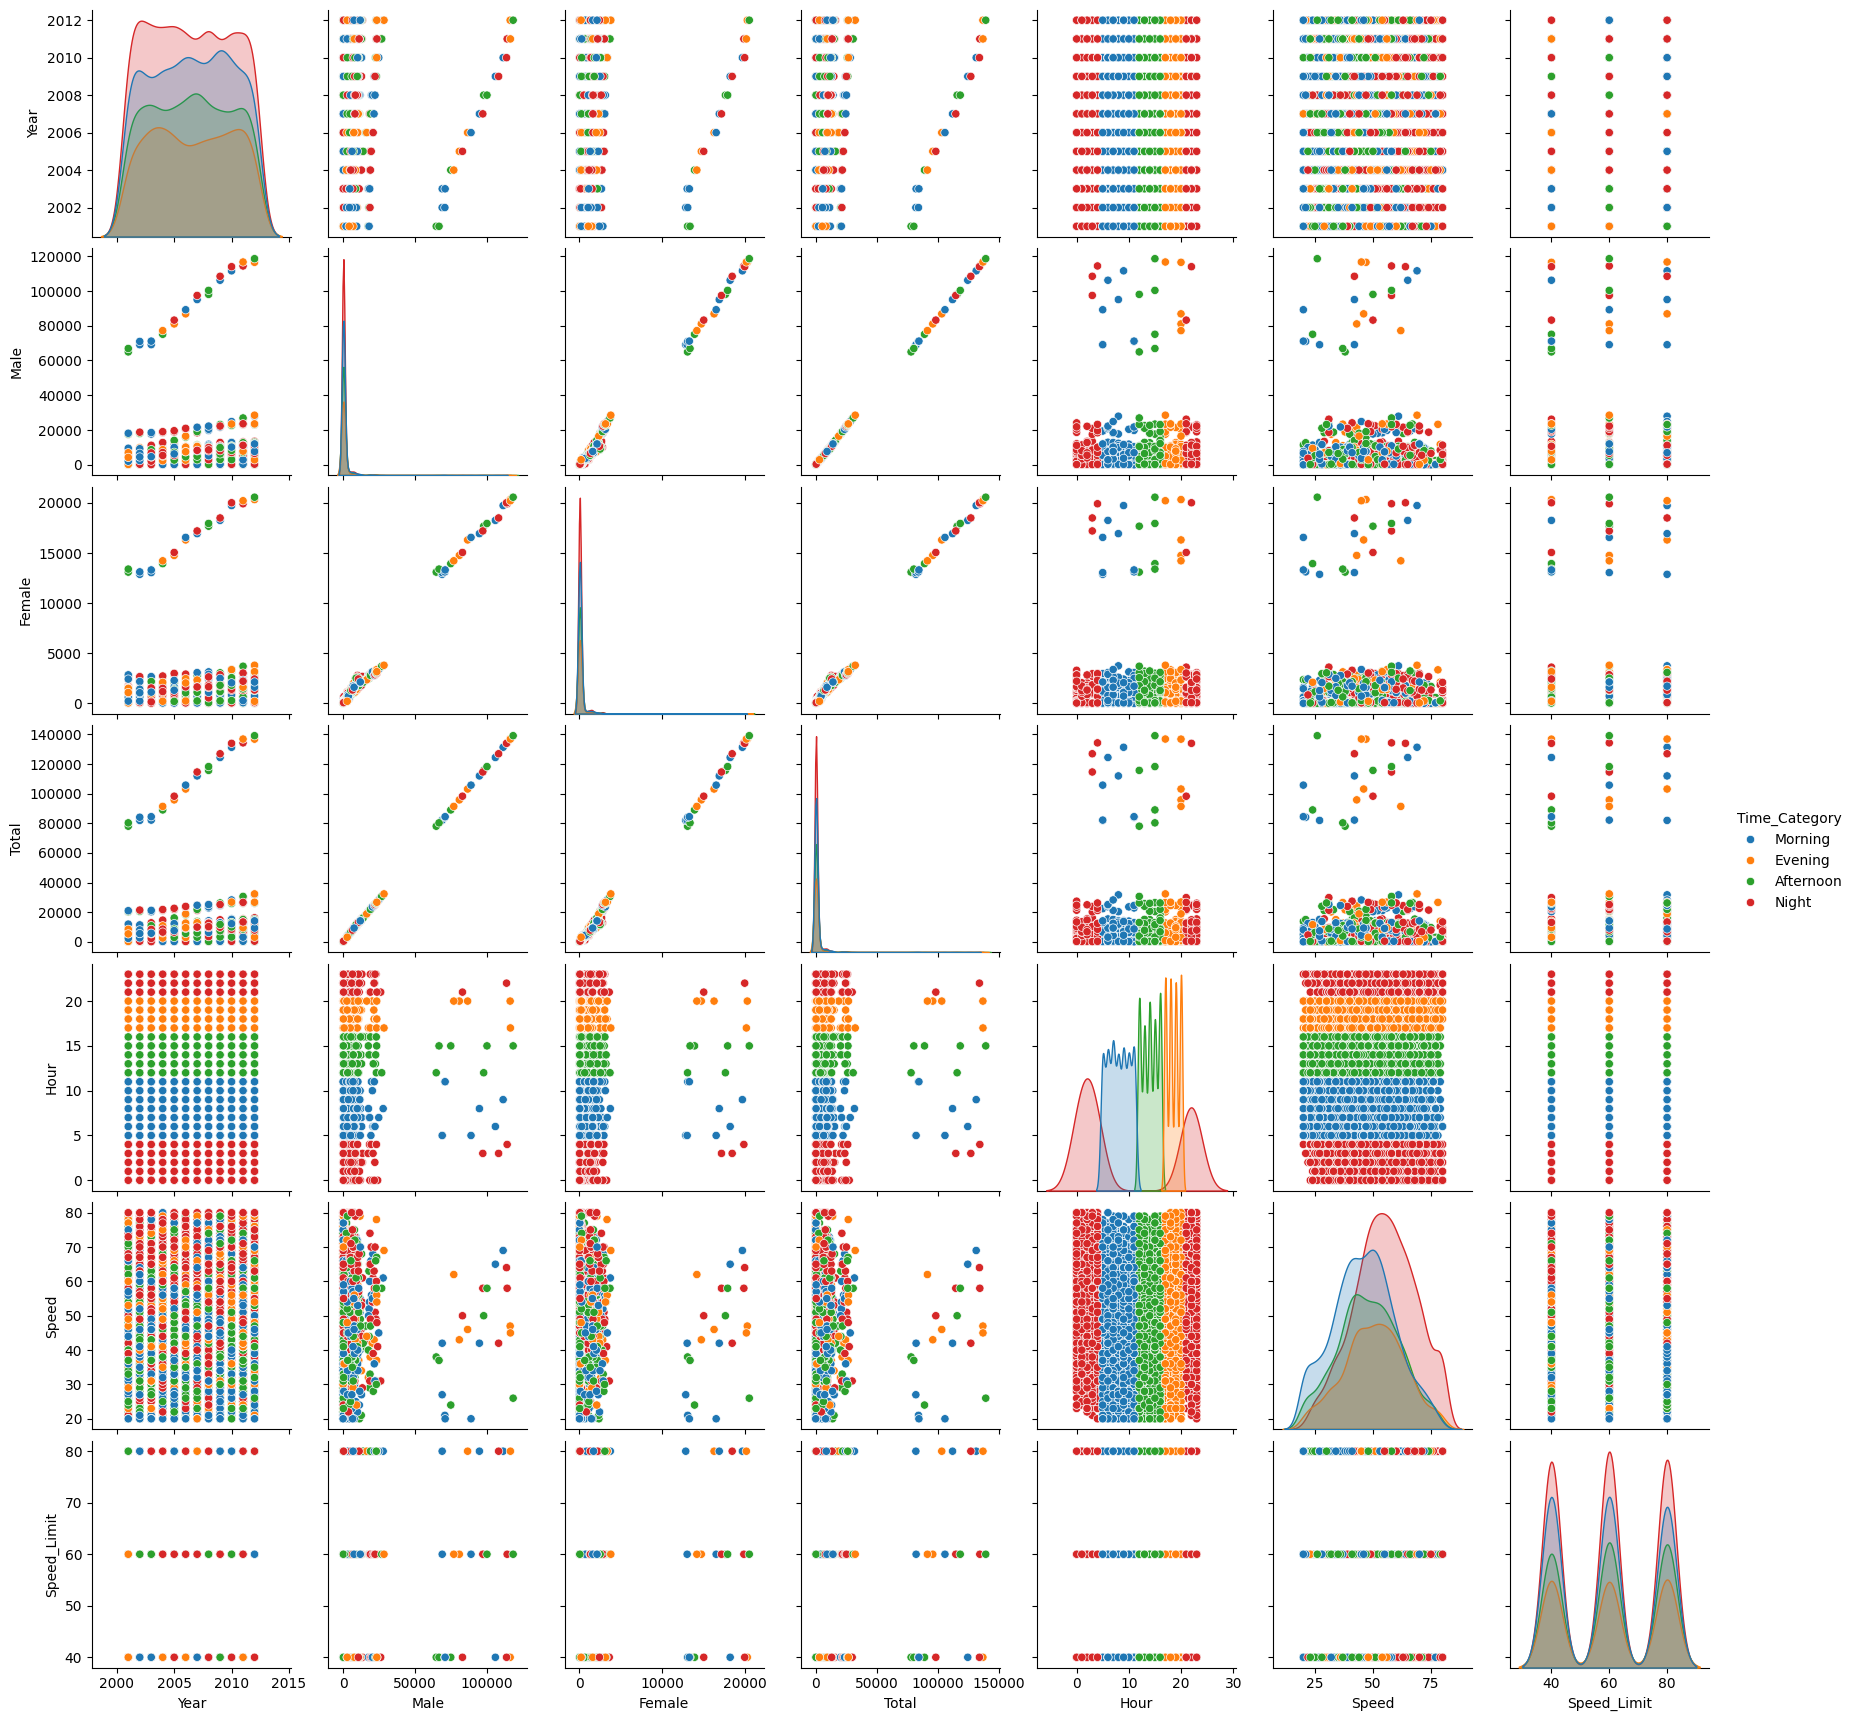

In [12]:
sns.pairplot(df, hue='Time_Category')

plt.show()

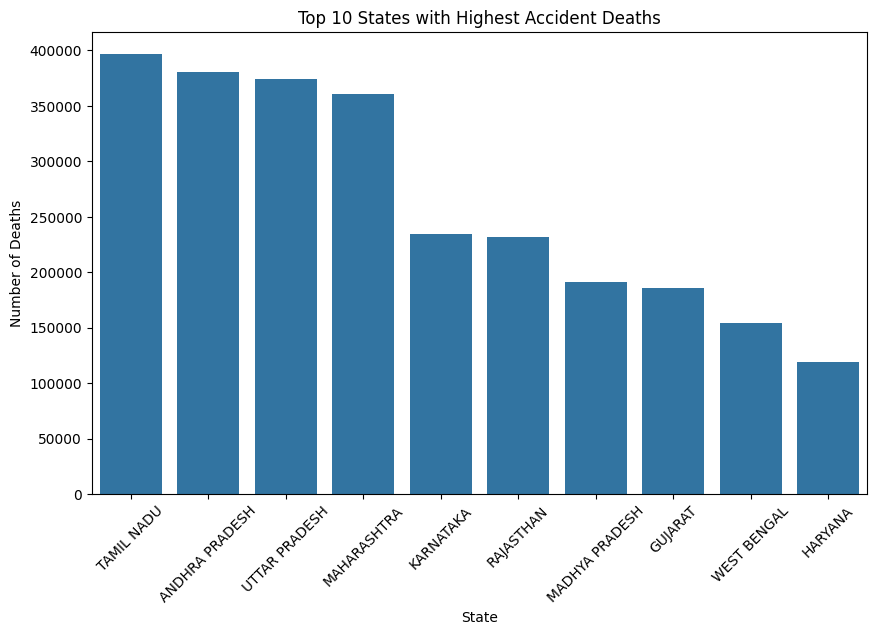

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("accident_dataset.csv")

# 🔥 Remove unwanted total rows
df = df[~df['STATE/UT'].str.upper().str.contains('TOTAL')]

# Top 10 states
top10 = df.groupby('STATE/UT')['Total'].sum().sort_values(ascending=False).head(10)

top10_df = top10.reset_index()

# Plot
plt.figure(figsize=(10,6))

sns.barplot(x='STATE/UT', y='Total', data=top10_df)

plt.xticks(rotation=45)
plt.title("Top 10 States with Highest Accident Deaths")
plt.xlabel("State")
plt.ylabel("Number of Deaths")

plt.show()

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("accident_dataset.csv")

y = df['Time_Category']

X = df[['Weather', 'Speed', 'Speed_Limit', 'Hour']]
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("accident_dataset.csv")

df_encoded = pd.get_dummies(df)

X = df_encoded.drop('Speed', axis=1)
y = df_encoded['Speed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("RF Score:", rf.score(X_test, y_test))

RF Score: 0.5521822583442475
